In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

seed= 42

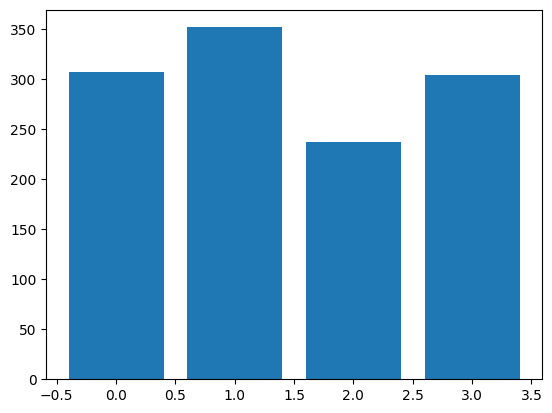

In [128]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

le= LabelEncoder()


X= train_df.drop(columns=['robot_id', 'strategy_label'])
y = le.fit_transform(train_df['strategy_label'])

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.9, random_state= seed, stratify= y)

X_test= test_df.drop(columns=['robot_id'])

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()


In [129]:
# Subtask 1
answer1=[]
answer1.append({
    'robot_id':'GLOBAL',
    'subtaskID': 1,
    'answer': len(np.unique(train_df['arena_type']))
})

answer1= pd.DataFrame(answer1)
answer1.head()

,robot_id,subtaskID,answer
0,GLOBAL,1,4


In [130]:
# Subtask 2

answer2=[]
answer2.append({
    'robot_id':'GLOBAL',
    'subtaskID': 2,
    'answer': np.max(train_df['avg_speed_mps'])
})

answer2= pd.DataFrame(answer2)
answer2.head()

,robot_id,subtaskID,answer
0,GLOBAL,2,2.6412


In [131]:
# Subtask 3

answer3=[]
answer3.append({
    'robot_id':'GLOBAL',
    'subtaskID': 3,
    'answer': train_df['arena_type'].value_counts().index[0]
})

answer3= pd.DataFrame(answer3)
answer3.head()

,robot_id,subtaskID,answer
0,GLOBAL,3,forest


In [132]:
# Subtask 4

answer4=[]
answer4.append({
    'robot_id':'GLOBAL',
    'subtaskID': 4,
    'answer': np.max(train_df['items_collected'])
})

answer4= pd.DataFrame(answer4)
answer4.head()

,robot_id,subtaskID,answer
0,GLOBAL,4,22


In [133]:
# Subtask 5
from catboost import CatBoostClassifier

cat_cols= list(X.select_dtypes(include= ['object', 'string']).columns)

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=1e-2,
    cat_features= cat_cols,
    auto_class_weights= 'Balanced',
    eval_metric='TotalF1',
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_eval, y_eval)],
    verbose= False
)

predictions= le.inverse_transform(np.ravel(model.predict(X_test)))

answer5= []

for id_, pred in zip(test_df['robot_id'], predictions):
    answer5.append({
    'robot_id': id_,
    'subtaskID': 5,
    'answer': pred
    })

answer5= pd.DataFrame(answer5)
answer5.head()

,robot_id,subtaskID,answer
0,TS_0000,5,guardian
1,TS_0001,5,guardian
2,TS_0002,5,explorer
3,TS_0003,5,sprinter
4,TS_0004,5,explorer


In [134]:
answer= pd.concat([answer1, answer2, answer3, answer4, answer5])
answer.to_csv("submission.csv", index= False)